

# Activity A1: Structural Characterization and Network Models

**Student:** - Omar Morales Ortega

**Master's Degree in Artificial Intelligence** **Course:** Complex Networks

**University:** Universitat Rovira i Virgili (URV)

---

## Overview
In this notebook, I work with several network datasets to explore their structural properties and better understand how they might have been generated. The analysis starts by loading graphs from Pajek (.net) files and taking a quick look at their basic characteristics.

Next, I compute a set of common network metrics, such as node degree, clustering coefficient, and assortativity, which help describe how the nodes in the network are connected.

To understand which nodes play the most important roles in the network, I also calculate different centrality measures, including degree, betweenness, and eigenvector centrality.

Finally, I visualize the degree distributions of the networks. By looking at these patterns, it becomes easier to compare the graphs with well-known network models like Erdős–Rényi (ER), Watts–Strogatz (WS), Barabási–Albert (BA), and Configuration Model (CM).


Importing the necessary libraries for network manipulation, numerical calculations, and data visualization.

In [44]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

This function loads a Pajek network file and calculates macroscopic properties. If the network is disconnected, it identifies the Largest Connected Component (LCC) to compute path length and diameter.

In [45]:
def analyze_network(file_path):
    print(f"\n{'='*40}")
    print(f"Analyzing {os.path.basename(file_path)}")
    print(f"{'='*40}")

    # 1. Load the Pajek (.net) network
    try:
        # read_pajek loads as a MultiGraph/MultiDiGraph
        G_raw = nx.read_pajek(file_path)
        # Convert to a standard undirected Graph for these specific metrics
        G = nx.Graph(G_raw) 
    except FileNotFoundError:
        print(f"Error: Could not find {file_path}. Please check the directory.")
        return None

    # 2. Basic Properties
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()

    # 3. Degree Analysis
    degrees = [d for n, d in G.degree()]
    min_deg = min(degrees)
    max_deg = max(degrees)
    avg_deg = sum(degrees) / num_nodes

    # 4. Clustering and Assortativity
    avg_clustering = nx.average_clustering(G)
    assortativity = nx.degree_assortativity_coefficient(G)

    # 5. Path Length and Diameter
    if nx.is_connected(G):
        avg_path_length = nx.average_shortest_path_length(G)
        diameter = nx.diameter(G)
    else:
        print(f"Note: Network is disconnected. Number of components: {nx.number_connected_components(G)}. Path metrics calculated for the Largest Connected Component.")
        components = nx.connected_components(G)
        largest_component = max(components, key=len)
        LCC = G.subgraph(largest_component)
        
        avg_path_length = nx.average_shortest_path_length(LCC)
        diameter = nx.diameter(LCC)

    # Print the calculated descriptors
    print(f"Number of nodes:       {num_nodes}")
    print(f"Number of edges:       {num_edges}")
    print(f"Minimum degree:        {min_deg}")
    print(f"Maximum degree:        {max_deg}")
    print(f"Average degree:        {avg_deg:.4f}")
    print(f"Avg Clustering Coeff:  {avg_clustering:.4f}")
    print(f"Assortativity:         {assortativity:.4f}")
    print(f"Avg Path Length:       {avg_path_length:.4f}")
    print(f"Diameter:              {diameter}")

    return degrees

Generates side-by-side plots of the degree distribution. The first uses a linear scale histogram, while the second uses a log-log scale with logarithmic binning to help identify scale-free properties.

In [46]:
def plot_degree_distribution(degrees, title):
    """
    Plots the degree distribution in both linear and log-log scale 
    (with logarithmic binning) side-by-side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1: Linear Scale Histogram ---
    axes[0].hist(degrees, bins=range(min(degrees), max(degrees) + 2), 
                 color='orangered', edgecolor='black', align='left')
    axes[0].set_title(f'{title} - Linear Scale')
    axes[0].set_xlabel('Degree (k)')
    axes[0].set_ylabel('Frequency P(k)')

    # --- Plot 2: Log-Log Scale with Logarithmic Binning ---
    if min(degrees) > 0:
        bins = np.logspace(np.log10(min(degrees)), np.log10(max(degrees)), num=20)
    else:
        bins = np.logspace(0, np.log10(max(degrees)), num=20)
        bins = np.insert(bins, 0, 0)

    hist, edges = np.histogram(degrees, bins=bins)
    bin_centers = (edges[:-1] + edges[1:]) / 2

    valid = hist > 0
    axes[1].plot(bin_centers[valid], hist[valid], marker='o', linestyle='', color='firebrick')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_title(f'{title} - Log-Log Scale (Log Binning)')
    axes[1].set_xlabel('Degree (k)')
    axes[1].set_ylabel('Frequency P(k)')

    plt.tight_layout()
    plt.show()

Iterates through the list of network files, calling the analysis and plotting functions for each.


Analyzing net1.net
Number of nodes:       5000
Number of edges:       25000
Minimum degree:        6
Maximum degree:        16
Average degree:        10.0000
Avg Clustering Coeff:  0.4141
Assortativity:         -0.0097
Avg Path Length:       5.1211
Diameter:              8


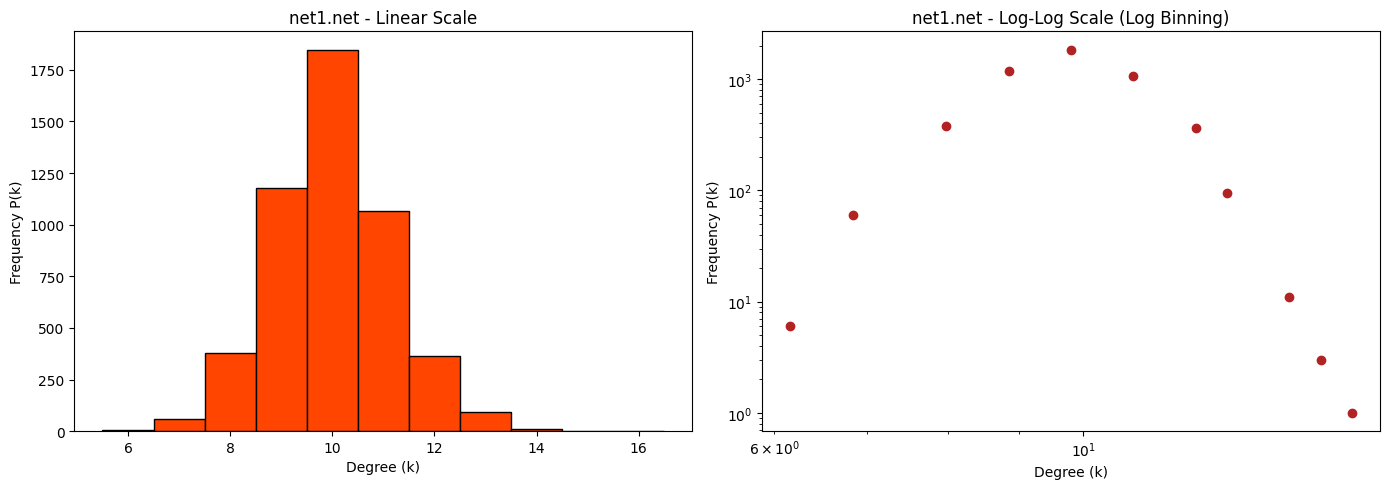


Analyzing net2.net
Number of nodes:       5000
Number of edges:       24873
Minimum degree:        1
Maximum degree:        24
Average degree:        9.9492
Avg Clustering Coeff:  0.0021
Assortativity:         -0.0057
Avg Path Length:       3.9560
Diameter:              7


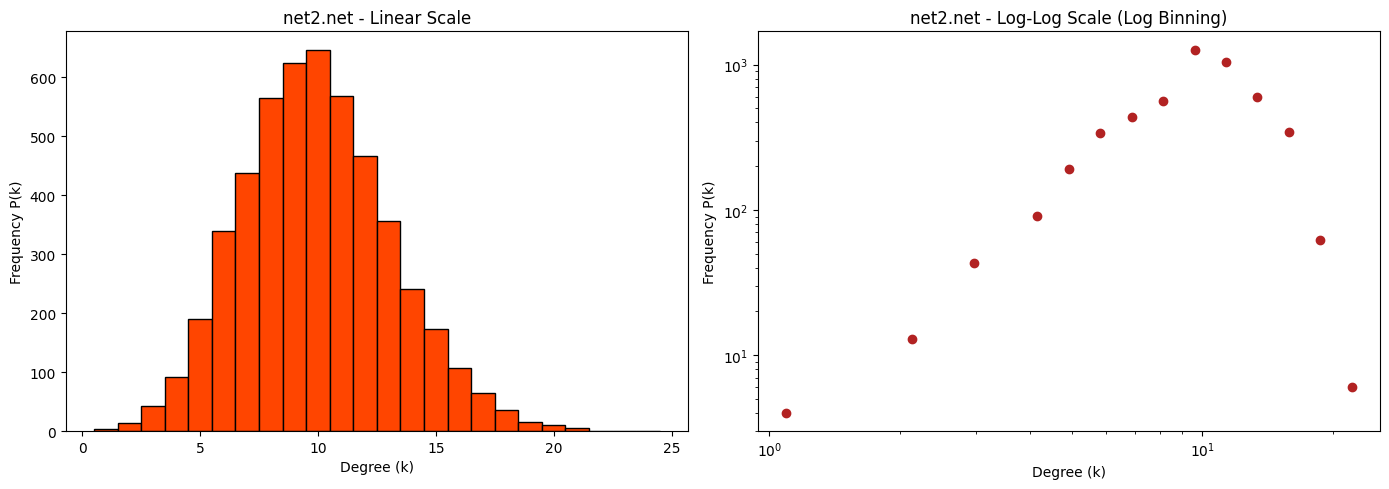


Analyzing net3.net
Number of nodes:       5000
Number of edges:       23508
Minimum degree:        3
Maximum degree:        732
Average degree:        9.4032
Avg Clustering Coeff:  0.0862
Assortativity:         -0.1339
Avg Path Length:       3.0082
Diameter:              5


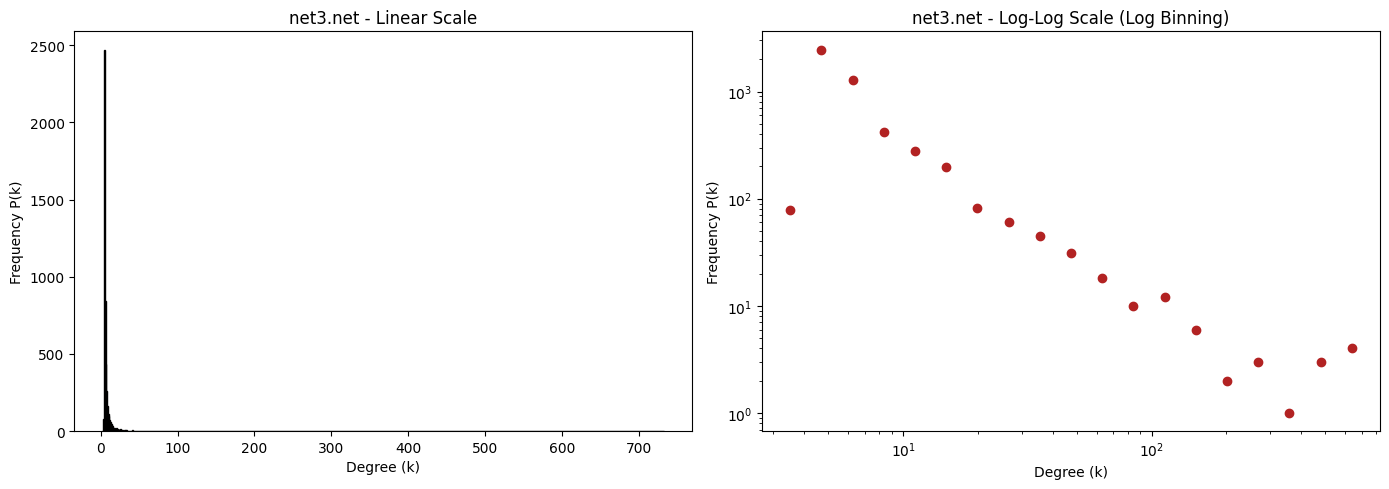


Analyzing net4.net
Number of nodes:       5000
Number of edges:       24975
Minimum degree:        5
Maximum degree:        210
Average degree:        9.9900
Avg Clustering Coeff:  0.0107
Assortativity:         -0.0325
Avg Path Length:       3.4868
Diameter:              5


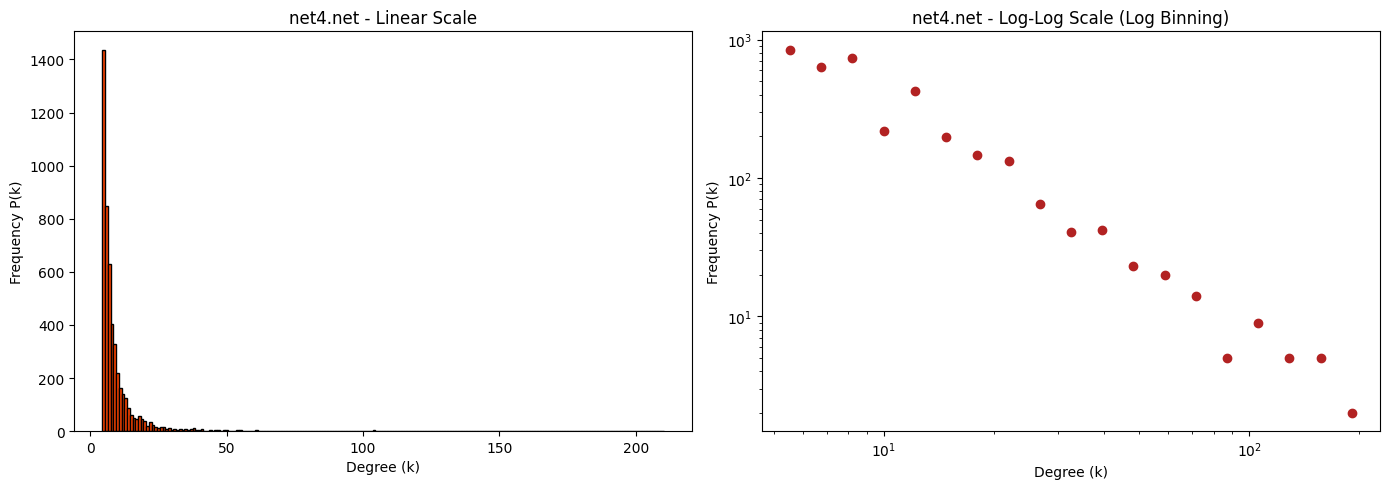

In [47]:
# Updated to .net extensions and specified path
network_files = ['net1.net', 'net2.net', 'net3.net', 'net4.net'] 
data_dir = os.path.join("data")

for file in network_files:
    file_path = os.path.join(data_dir, file)
    degrees = analyze_network(file_path)
    if degrees:
        plot_degree_distribution(degrees, title=file)

This cell contains a Python function that calculates the three centralities (betweenness, degree, eigenvector). It sorts the results to find the top 5 nodes and prints them in a clean table format that is easy to read.

In [48]:
def get_top_5_centralities(G, name):
    print(f"\n--- Exact Centrality Analysis for {name} ---")
    
    # 1. Degree
    degree_dict = dict(G.degree())
    top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:5]
    
    # 2. Exact Betweenness (Removed k)
    print(f"Calculating exact betweenness for {name} (this may take a few minutes)...")
    between_dict = nx.betweenness_centrality(G, normalized=True)
    top_between = sorted(between_dict.items(), key=lambda x: x[1], reverse=True)[:5]
    
    # 3. Eigenvector
    try:
        eig_dict = nx.eigenvector_centrality(G, max_iter=1000)
    except nx.PowerIterationFailedConvergence:
        eig_dict = nx.eigenvector_centrality_numpy(G)
    top_eig = sorted(eig_dict.items(), key=lambda x: x[1], reverse=True)[:5]

    # Display results
    print(f"{'Rank':<5} | {'Degree':<15} | {'Betweenness':<15} | {'Eigenvector':<15}")
    print("-" * 65)
    for i in range(5):
        deg_str = f"ID:{top_degree[i][0]} ({top_degree[i][1]})"
        bet_str = f"ID:{top_between[i][0]} ({top_between[i][1]:.5f})"
        eig_str = f"ID:{top_eig[i][0]} ({top_eig[i][1]:.5f})"
        print(f"{i+1:<5} | {deg_str:<15} | {bet_str:<15} | {eig_str:<15}")

This cell runs the analysis for each of our networks (net1, net2, net3, and net4). Note that This cell may take several minutes to finish as it checks every possible path in the 5,000-node networks.

In [49]:


for file in network_files:
    file_path = os.path.join(data_dir, file)
    try:
        # read_pajek loads as a MultiGraph/MultiDiGraph
        G_raw = nx.read_pajek(file_path)
        # Convert to a standard undirected Graph for these specific metrics
        G = nx.Graph(G_raw) 
    except FileNotFoundError:
        print(f"Error: Could not find {file_path}. Please check the directory.")
        continue
    get_top_5_centralities(G, file)


--- Exact Centrality Analysis for net1.net ---
Calculating exact betweenness for net1.net (this may take a few minutes)...
Rank  | Degree          | Betweenness     | Eigenvector    
-----------------------------------------------------------------
1     | ID:1693 (16)    | ID:4747 (0.00406) | ID:651 (0.02863)
2     | ID:651 (15)     | ID:2645 (0.00405) | ID:1937 (0.02647)
3     | ID:1579 (15)    | ID:230 (0.00380) | ID:4526 (0.02563)
4     | ID:4891 (15)    | ID:4360 (0.00379) | ID:4398 (0.02525)
5     | ID:41 (14)      | ID:1579 (0.00366) | ID:1939 (0.02517)

--- Exact Centrality Analysis for net2.net ---
Calculating exact betweenness for net2.net (this may take a few minutes)...
Rank  | Degree          | Betweenness     | Eigenvector    
-----------------------------------------------------------------
1     | ID:1581 (24)    | ID:1581 (0.00330) | ID:1581 (0.04122)
2     | ID:787 (23)     | ID:787 (0.00256) | ID:3233 (0.03434)
3     | ID:52 (21)      | ID:4382 (0.00246) | ID:787 (0

This cell defines a function that takes a network, calculates all three centralities, and computes the Spearman correlation between each pair. 

In [50]:
from scipy.stats import spearmanr

def compute_centrality_correlations(G, name):
    """
    Calculates the Spearman correlation between Degree, Betweenness, 
    and Eigenvector centralities for a given network.
    """
    print(f"Analyzing correlations for {name}...")
    
    # 1. Calculate Centralities
    # We use the full dictionaries for every node to get accurate correlation
    deg_cent = nx.degree_centrality(G)
    bet_cent = nx.betweenness_centrality(G)
    try:
        eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
    except:
        eig_cent = nx.eigenvector_centrality_numpy(G)
        
    # 2. Align values into lists for comparison
    # It is important to ensure the nodes are in the same order
    nodes = sorted(G.nodes())
    deg_values = [deg_cent[n] for n in nodes]
    bet_values = [bet_cent[n] for n in nodes]
    eig_values = [eig_cent[n] for n in nodes]
    
    # 3. Compute Spearman Correlations
    corr_deg_bet, _ = spearmanr(deg_values, bet_values)
    corr_deg_eig, _ = spearmanr(deg_values, eig_values)
    corr_bet_eig, _ = spearmanr(bet_values, eig_values)
    
    return {
        "Network": name,
        "Degree vs Betweenness": round(corr_deg_bet, 4),
        "Degree vs Eigenvector": round(corr_deg_eig, 4),
        "Betweenness vs Eigenvector": round(corr_bet_eig, 4)
    }

This cell runs the function across all four of our networks and stores the results in a single DataFrame.

In [51]:
# List to store result dictionaries
results_list = []

for file in network_files:
    file_path = os.path.join(data_dir, file)
    try:
        # read_pajek loads as a MultiGraph/MultiDiGraph
        G_raw = nx.read_pajek(file_path)
        # Convert to a standard undirected Graph for these specific metrics
        G = nx.Graph(G_raw) 
        results_list.append(compute_centrality_correlations(G, file))
    except FileNotFoundError:
        print(f"Error: Could not find {file_path}. Please check the directory.")
        continue

correlation_table = pd.DataFrame(results_list)

print("\n--- Final Spearman Correlation Table ---")
print(correlation_table.to_string(index=False))

Analyzing correlations for net1.net...
Analyzing correlations for net2.net...
Analyzing correlations for net3.net...
Analyzing correlations for net4.net...

--- Final Spearman Correlation Table ---
 Network  Degree vs Betweenness  Degree vs Eigenvector  Betweenness vs Eigenvector
net1.net                 0.6217                 0.7157                      0.4559
net2.net                 0.9919                 0.9436                      0.9552
net3.net                 0.6089                 0.4651                      0.7061
net4.net                 0.8915                 0.5628                      0.7894


Regenerate the evidence to identify the model.

In [52]:

def get_evidence(G, name):
    C = nx.average_clustering(G)
    L = nx.average_shortest_path_length(G)
    degrees = [d for n, d in G.degree()]
    k_max = max(degrees)
    
    # Simple Gamma estimation (Hill Estimator style)
    k_min = min(degrees) if min(degrees) > 0 else 1
    gamma = 1 + len(degrees) * (sum(np.log(d/k_min) for d in degrees if d > 0))**-1
    
    print(f"{name}: C={C:.4f}, L={L:.4f}, MaxK={k_max}, Est. Gamma={gamma:.2f}")


for file in network_files:
    file_path = os.path.join(data_dir, file)
    try:
        # read_pajek loads as a MultiGraph/MultiDiGraph
        G_raw = nx.read_pajek(file_path)
        # Convert to a standard undirected Graph for these specific metrics
        G = nx.Graph(G_raw) 
        get_evidence(G, file)
    except FileNotFoundError:
        print(f"Error: Could not find {file_path}. Please check the directory.")
        continue

net1.net: C=0.4141, L=5.1211, MaxK=16, Est. Gamma=2.98
net2.net: C=0.0021, L=3.9560, MaxK=24, Est. Gamma=1.45
net3.net: C=0.0862, L=3.0082, MaxK=732, Est. Gamma=2.24
net4.net: C=0.0107, L=3.4868, MaxK=210, Est. Gamma=3.12


This cell loads the positions.txt file and maps those coordinates to the network nodes. We then plot the network to observe its geometric structure.

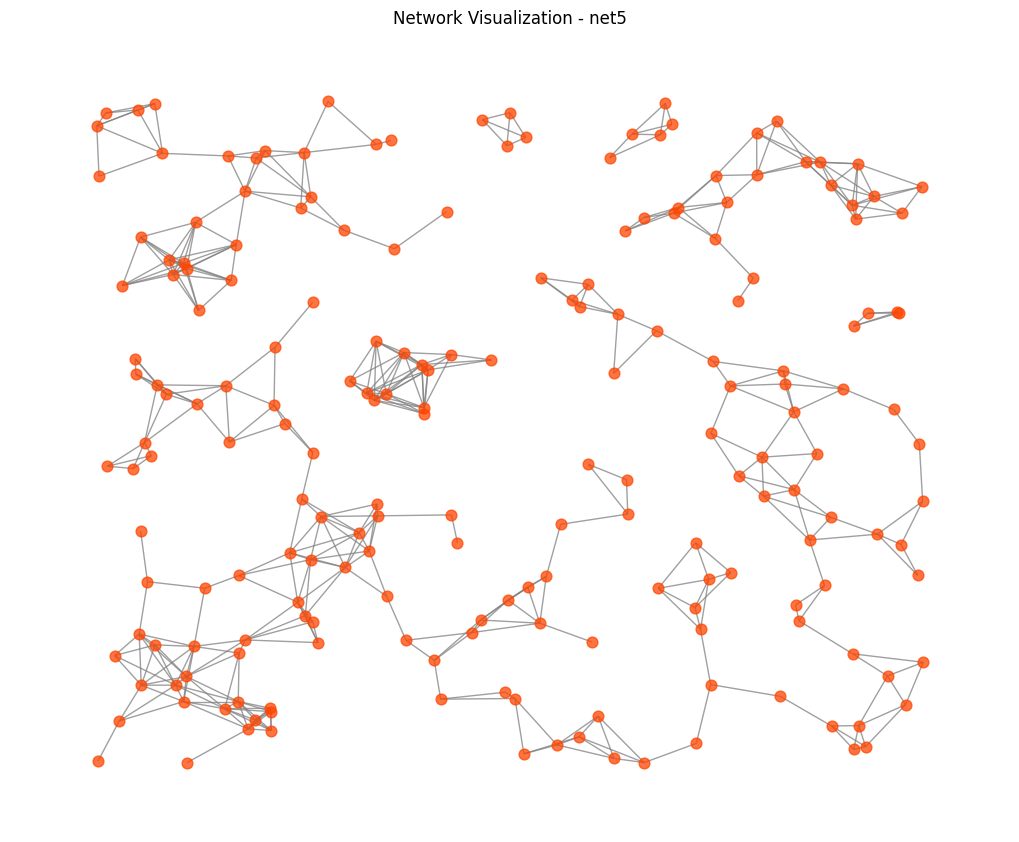


Analyzing net5.net
Note: Network is disconnected. Number of components: 7. Path metrics calculated for the Largest Connected Component.
Number of nodes:       200
Number of edges:       465
Minimum degree:        1
Maximum degree:        10
Average degree:        4.6500
Avg Clustering Coeff:  0.6107
Assortativity:         0.5502
Avg Path Length:       13.1310
Diameter:              35


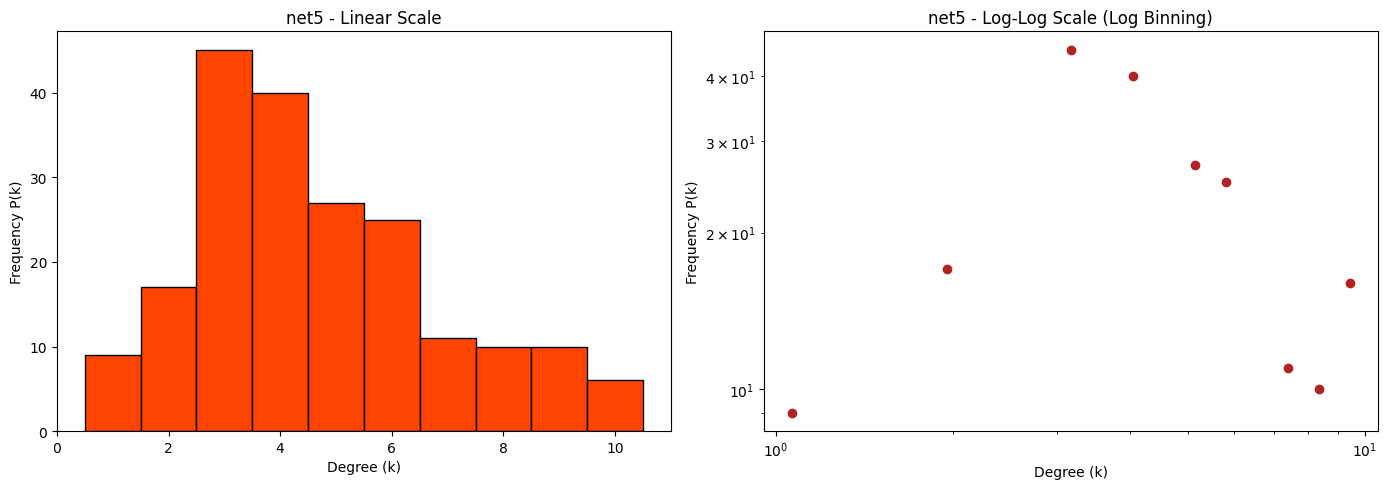

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

def build_network(file_net, position_net):
    G = nx.read_pajek(file_net)
    G = nx.Graph(G)
    
    pos_df = pd.read_csv(position_net, sep="\t")
    positions = {str(int(row["Node"])): (row["x"], row["y"]) for _, row in pos_df.iterrows()}  

    plt.figure(figsize=(10, 8))
    nx.draw(G, pos=positions, node_size=60, node_color="orangered", edge_color="gray", alpha=0.75)
    plt.title("Network Visualization - net5")
    
    plt.show()

# Run the analysis
file_path = os.path.join(data_dir, "net5.net")
positions_path = os.path.join(data_dir, "positions_net5.txt")
build_network(file_path, positions_path)
degrees = analyze_network(file_path)
if degrees:
    plot_degree_distribution(degrees, title="net5")

